In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [3]:
df_train = pd.read_csv('/content/train.csv')

In [4]:
df_train.head()

,ID,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,196348,0,Cash loans,F,N,Y,2,225000.0,785398.5,33403.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1,147976,0,Cash loans,M,N,Y,0,90000.0,592560.0,35937.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,52662,0,Revolving loans,F,N,Y,1,126000.0,202500.0,10125.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0
3,101577,0,Cash loans,F,N,Y,0,157500.0,254700.0,18531.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,173078,0,Cash loans,F,Y,N,0,540000.0,1252363.5,47830.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.0


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17539 entries, 0 to 17538
Columns: 122 entries, ID to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(94), int64(12), object(16)
memory usage: 16.3+ MB


In [6]:
df_train.shape

(17539, 122)

<Axes: >

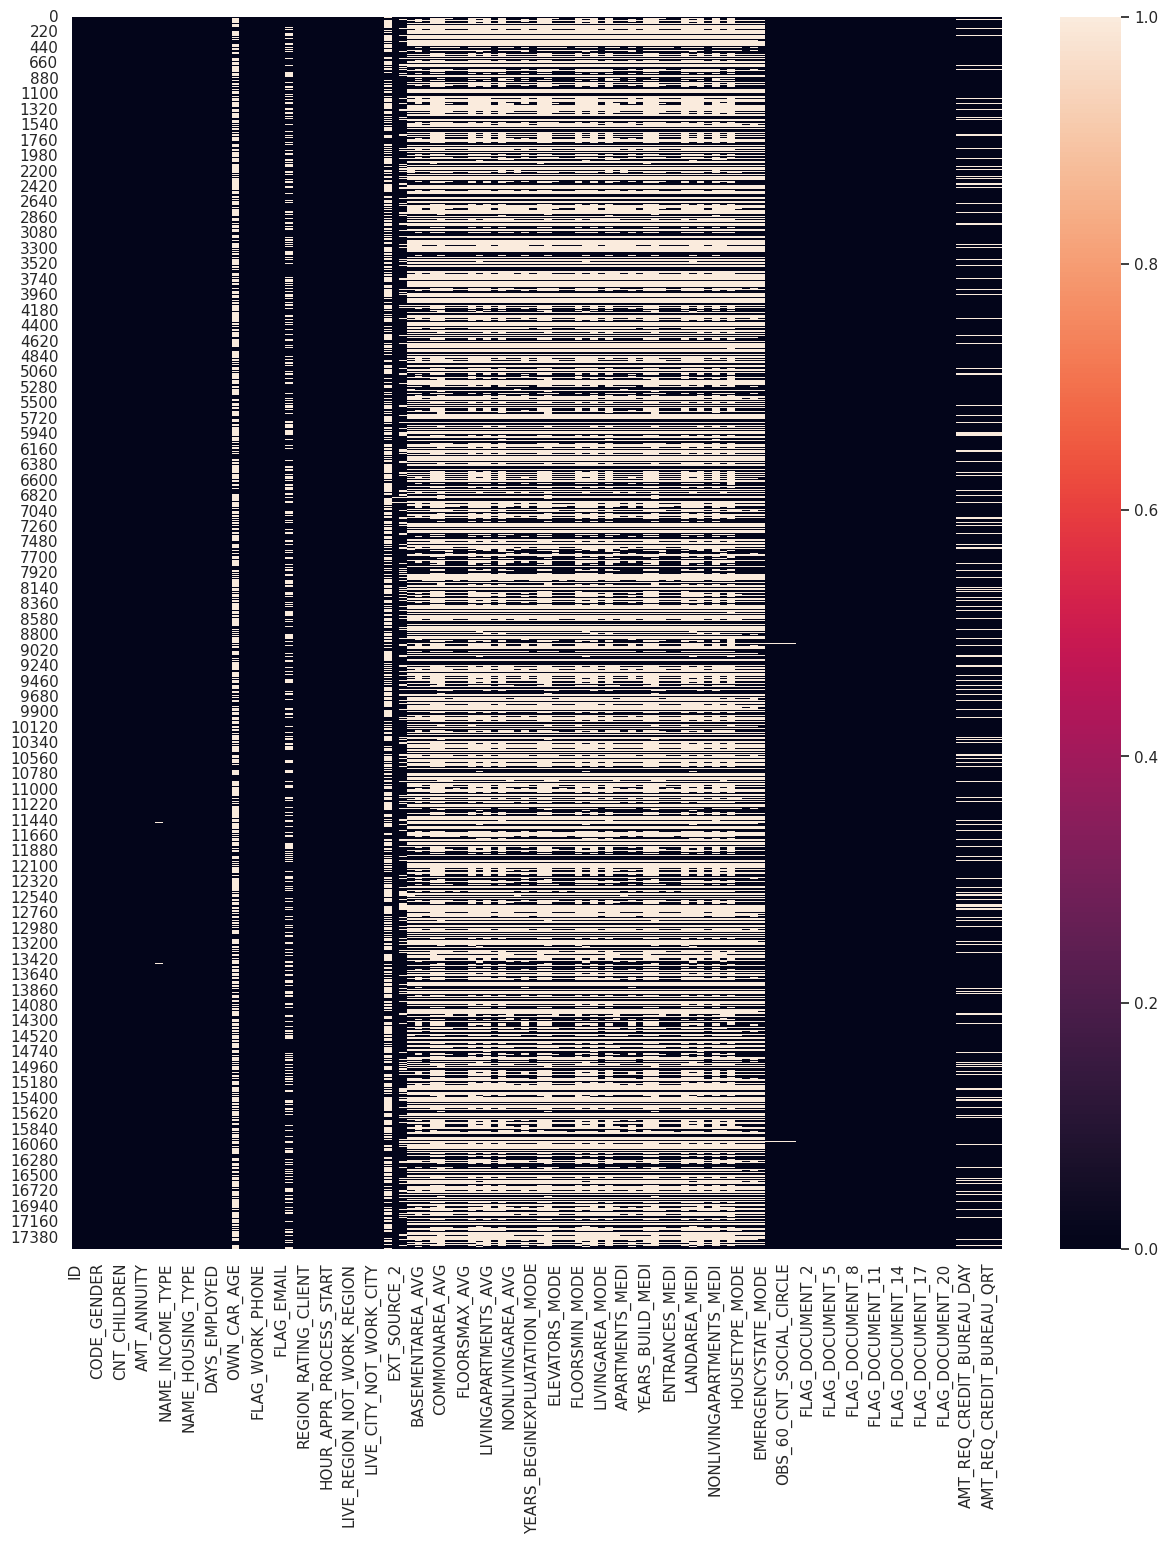

In [7]:
plt.figure(figsize = (15,16))
sns.heatmap(df_train.isnull())

<Axes: xlabel='TARGET', ylabel='count'>

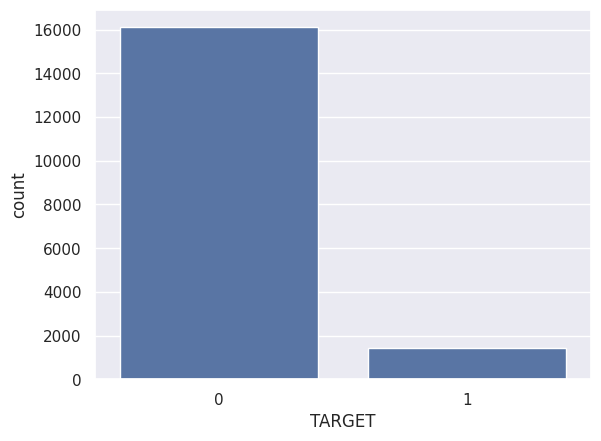

In [8]:
sns.countplot(x = 'TARGET', data = df_train)

In [9]:
column_names = df_train.columns.tolist()
null_counts = df_train.isnull().sum().tolist()
for name, count in zip(column_names, null_counts):
    print(f"{name}: {count}")

ID: 0
TARGET: 0
NAME_CONTRACT_TYPE: 0
CODE_GENDER: 0
FLAG_OWN_CAR: 0
FLAG_OWN_REALTY: 0
CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 13
NAME_TYPE_SUITE: 71
NAME_INCOME_TYPE: 0
NAME_EDUCATION_TYPE: 0
NAME_FAMILY_STATUS: 0
NAME_HOUSING_TYPE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_BIRTH: 0
DAYS_EMPLOYED: 0
DAYS_REGISTRATION: 0
DAYS_ID_PUBLISH: 0
OWN_CAR_AGE: 11592
FLAG_MOBIL: 0
FLAG_EMP_PHONE: 0
FLAG_WORK_PHONE: 0
FLAG_CONT_MOBILE: 0
FLAG_PHONE: 0
FLAG_EMAIL: 0
OCCUPATION_TYPE: 5430
CNT_FAM_MEMBERS: 1
REGION_RATING_CLIENT: 1
REGION_RATING_CLIENT_W_CITY: 1
WEEKDAY_APPR_PROCESS_START: 1
HOUR_APPR_PROCESS_START: 1
REG_REGION_NOT_LIVE_REGION: 1
REG_REGION_NOT_WORK_REGION: 1
LIVE_REGION_NOT_WORK_REGION: 1
REG_CITY_NOT_LIVE_CITY: 1
REG_CITY_NOT_WORK_CITY: 1
LIVE_CITY_NOT_WORK_CITY: 1
ORGANIZATION_TYPE: 1
EXT_SOURCE_1: 9945
EXT_SOURCE_2: 32
EXT_SOURCE_3: 3463
APARTMENTS_AVG: 8885
BASEMENTAREA_AVG: 10256
YEARS_BEGINEXPLUATATION_AVG: 8542
YEARS_BUILD_AVG: 11607
C

Col - Amount Annuity - AMT_ANNUITY

In [ ]:
df_train['AMT_ANNUITY'].unique()

array([33403.5, 35937. , 10125. , ..., 57289.5, 69421.5, 10170. ])

<Axes: xlabel='AMT_ANNUITY'>

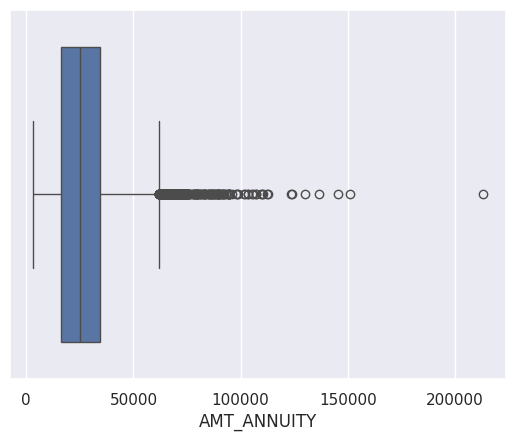

In [10]:
sns.boxplot(x='AMT_ANNUITY', data= df_train)

In [11]:
df = df_train.copy()

In [12]:
df['AMT_ANNUITY'].isnull().sum()

0

In [13]:
df['AMT_ANNUITY'] = df['AMT_ANNUITY'].fillna(df['AMT_ANNUITY'].median())
df['AMT_ANNUITY'].isnull().sum()

0

In [ ]:
#hold - not runed
#df['AMT_ANNUITY']=np.log1p(df_train['AMT_ANNUITY']) # Log transformation
#sns.boxplot(x='AMT_ANNUITY', data=df)

<Axes: xlabel='AMT_ANNUITY', ylabel='Count'>

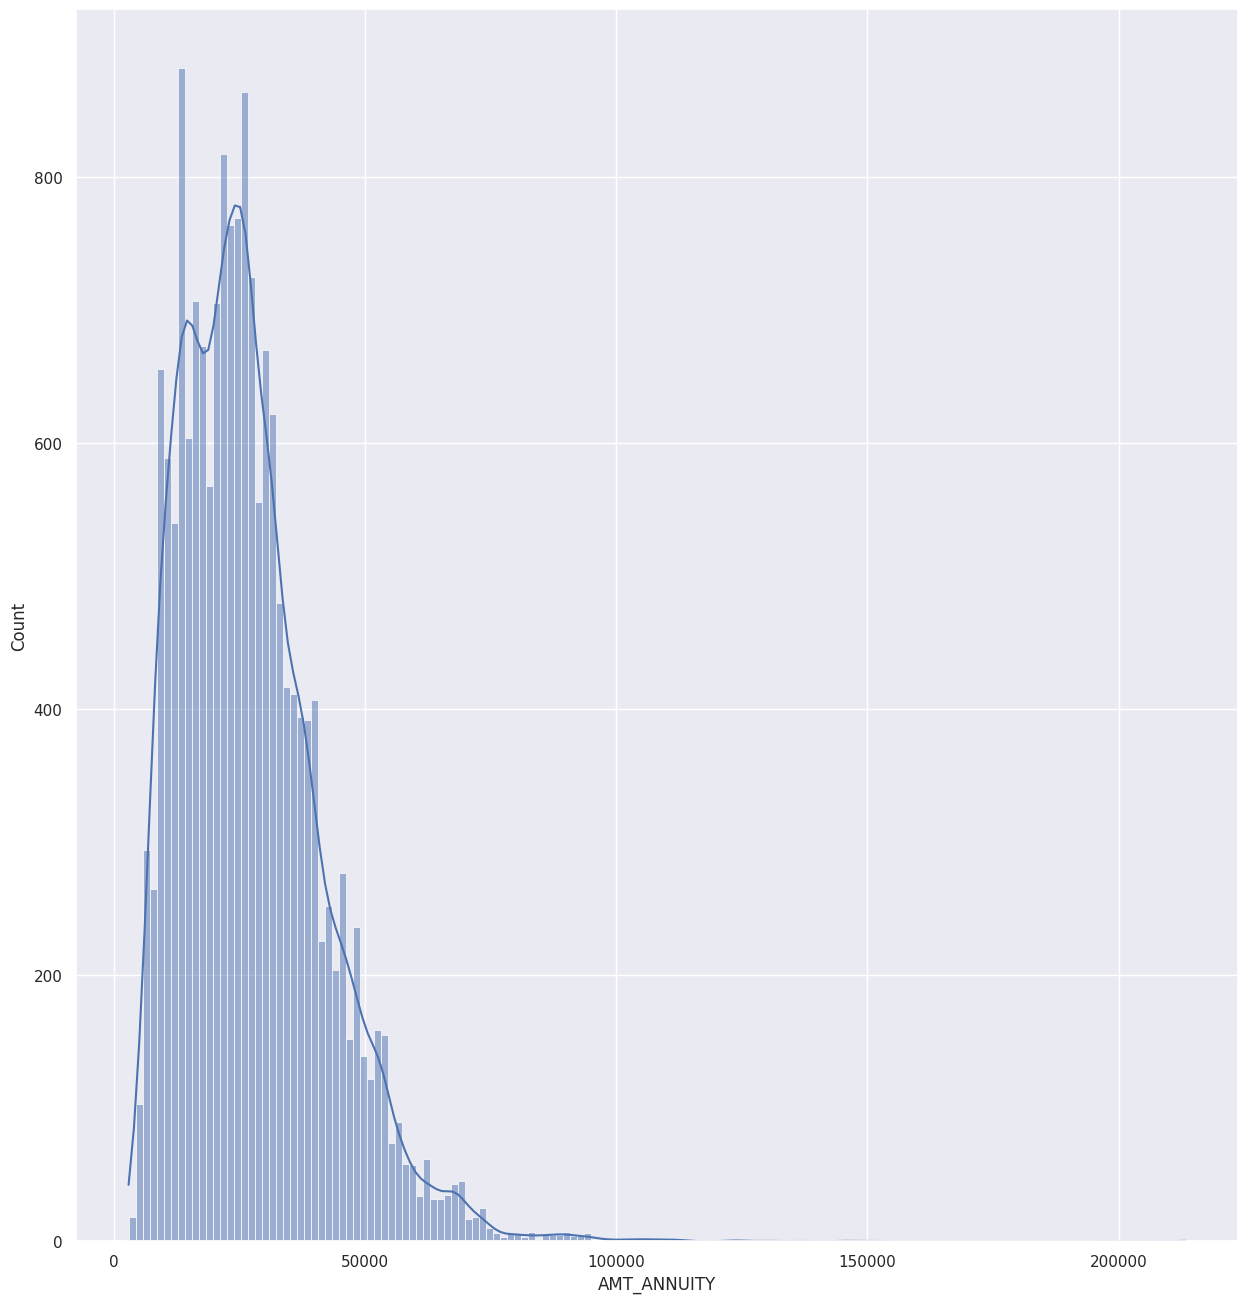

In [14]:
plt.figure(figsize=(15,16))
sns.histplot(x = df['AMT_ANNUITY'], kde=True)

Col - AMT_GOODS_PRICE

In [15]:
df['AMT_GOODS_PRICE'].isnull().sum()

13

<Axes: xlabel='AMT_GOODS_PRICE', ylabel='Count'>

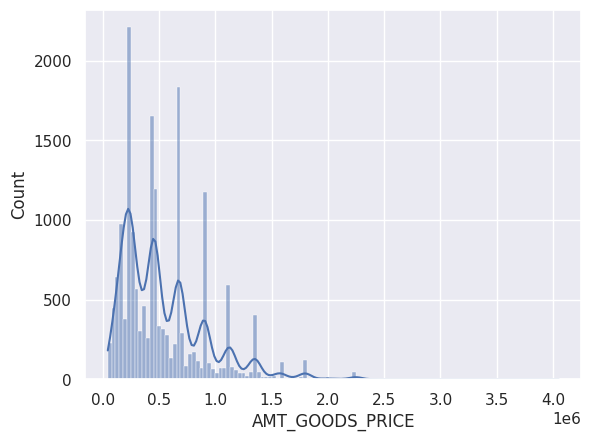

In [16]:
sns.histplot(x = df['AMT_GOODS_PRICE'], kde=True)

replace nan value with median

In [17]:
df['AMT_GOODS_PRICE'] = df['AMT_GOODS_PRICE'].fillna(df['AMT_GOODS_PRICE'].median())
df['AMT_GOODS_PRICE'].isnull().sum()

0

In [18]:
df['NAME_TYPE_SUITE'].value_counts()

,count
NAME_TYPE_SUITE,
Unaccompanied,14146
Family,2268
"Spouse, partner",674
Children,196
Other_B,119
Other_A,47
Group of people,18


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Unaccompanied'),
  Text(1, 0, 'Children'),
  Text(2, 0, 'Family'),
  Text(3, 0, 'Spouse, partner'),
  Text(4, 0, 'Other_B'),
  Text(5, 0, 'Other_A'),
  Text(6, 0, 'Group of people')])

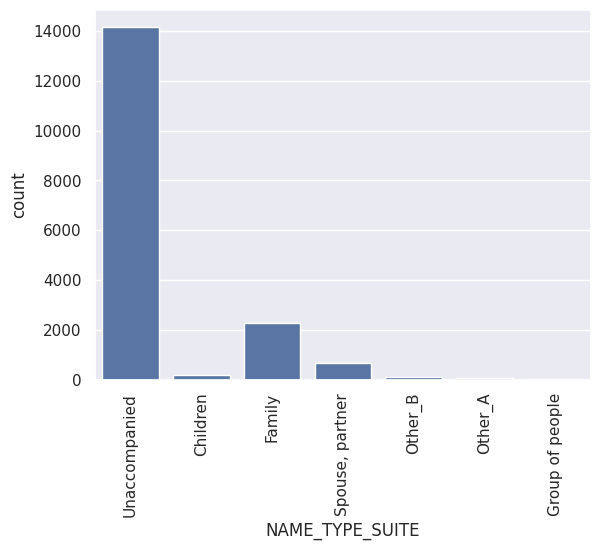

In [19]:
sns.countplot(x = 'NAME_TYPE_SUITE', data=df)
plt.xticks(rotation=90)

In [20]:
df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].fillna('Unaccompanied')
df['NAME_TYPE_SUITE'].isnull().sum()

0

col - OWN_CAR_AGE

In [21]:
df['OWN_CAR_AGE'].isnull().sum()

11592

using log1p (which is equivalent to applying the natural logarithm to 1 + x , i.e log(1+x)) can help reduce the influence of outliers, especially when the data has a heavy tail (a few extreme values).

1. Reduces Skewness
2. Handles Zero and Negative Values

Disadvantages of Using
1. Interpretation Complexity
2. Loss of Information

<Axes: xlabel='OWN_CAR_AGE'>

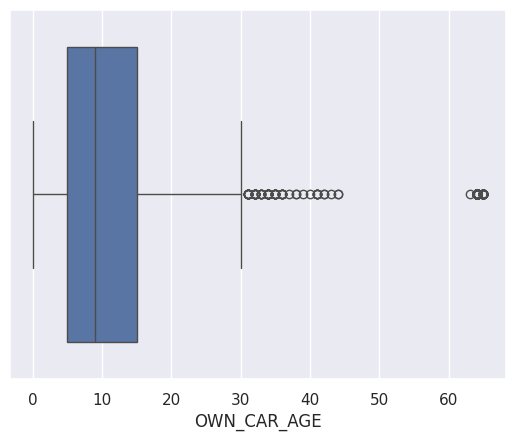

In [22]:
sns.boxplot(x = 'OWN_CAR_AGE', data = df)

<Axes: xlabel='OWN_CAR_AGE'>

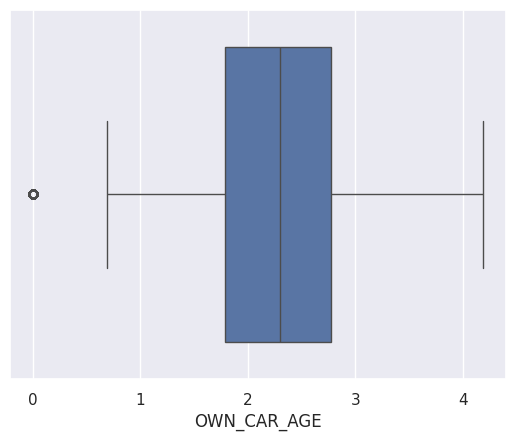

In [23]:
df_train['OWN_CAR_AGE'] = np.log1p(df_train['OWN_CAR_AGE'])
sns.boxplot(x = df_train['OWN_CAR_AGE'])

<Axes: xlabel='OWN_CAR_AGE', ylabel='Count'>

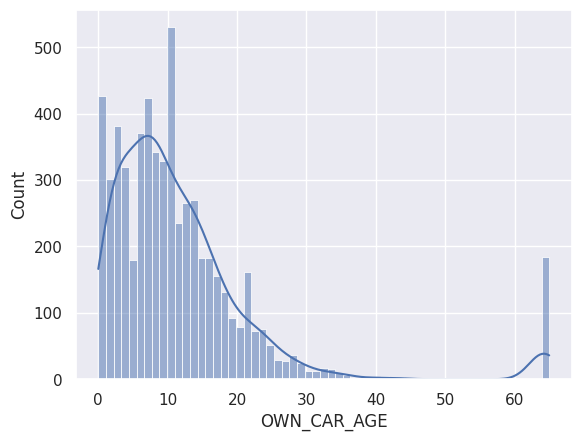

In [24]:
sns.histplot(x='OWN_CAR_AGE', data=df, kde=True)

Remove the Column
If a feature has too many missing values (for example, more than 50% - 70% of the data is missing)

In [25]:
df = df.dropna(axis=1, thresh=int(0.5 * len(df)))

In [26]:
df.shape

(17539, 81)

In [27]:
name_col = df.columns.tolist()
null_col = df.isnull().sum().tolist()
for (name, null) in zip(name_col, null_col):
    print(f'{name}: {null}')

ID: 0
TARGET: 0
NAME_CONTRACT_TYPE: 0
CODE_GENDER: 0
FLAG_OWN_CAR: 0
FLAG_OWN_REALTY: 0
CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 0
NAME_TYPE_SUITE: 0
NAME_INCOME_TYPE: 0
NAME_EDUCATION_TYPE: 0
NAME_FAMILY_STATUS: 0
NAME_HOUSING_TYPE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_BIRTH: 0
DAYS_EMPLOYED: 0
DAYS_REGISTRATION: 0
DAYS_ID_PUBLISH: 0
FLAG_MOBIL: 0
FLAG_EMP_PHONE: 0
FLAG_WORK_PHONE: 0
FLAG_CONT_MOBILE: 0
FLAG_PHONE: 0
FLAG_EMAIL: 0
OCCUPATION_TYPE: 5430
CNT_FAM_MEMBERS: 1
REGION_RATING_CLIENT: 1
REGION_RATING_CLIENT_W_CITY: 1
WEEKDAY_APPR_PROCESS_START: 1
HOUR_APPR_PROCESS_START: 1
REG_REGION_NOT_LIVE_REGION: 1
REG_REGION_NOT_WORK_REGION: 1
LIVE_REGION_NOT_WORK_REGION: 1
REG_CITY_NOT_LIVE_CITY: 1
REG_CITY_NOT_WORK_CITY: 1
LIVE_CITY_NOT_WORK_CITY: 1
ORGANIZATION_TYPE: 1
EXT_SOURCE_2: 32
EXT_SOURCE_3: 3463
YEARS_BEGINEXPLUATATION_AVG: 8542
FLOORSMAX_AVG: 8693
YEARS_BEGINEXPLUATATION_MODE: 8542
FLOORSMAX_MODE: 8693
YEARS_BEGINEXPLUATATION_MEDI: 854

In [28]:
df['YEARS_BEGINEXPLUATATION_AVG'].value_counts()

,count
YEARS_BEGINEXPLUATATION_AVG,
0.9806,258
0.9876,250
0.9831,244
0.9851,241
0.9801,241
...,...
0.9364,1
0.9439,1
0.9314,1


,YEARS_BEGINEXPLUATATION_AVG
count,8997.000000
mean,0.979291
std,0.045056
min,0.000000
25%,0.976700
50%,0.981600
75%,0.986600
max,1.000000


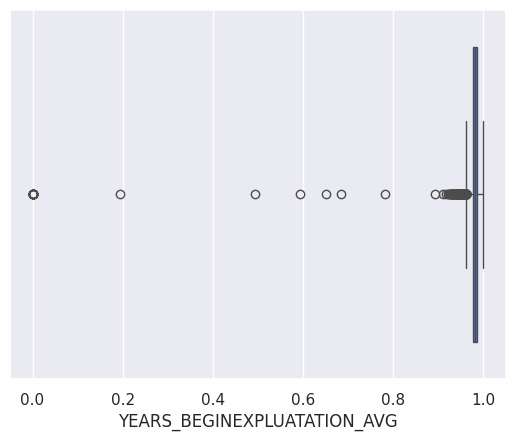

In [29]:
sns.boxplot(x='YEARS_BEGINEXPLUATATION_AVG', data = df)
df['YEARS_BEGINEXPLUATATION_AVG'].describe()

<Axes: xlabel='YEARS_BEGINEXPLUATATION_AVG', ylabel='Count'>

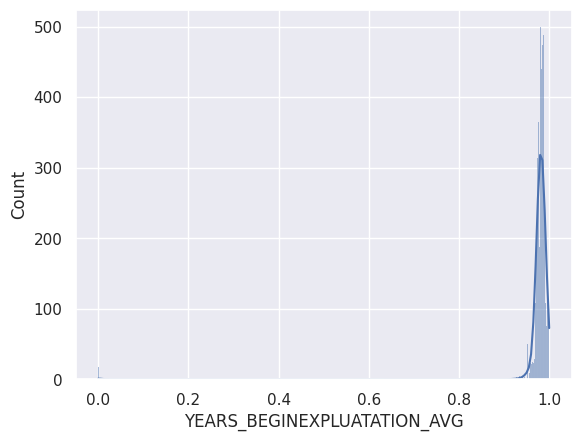

In [30]:
sns.histplot(x = 'YEARS_BEGINEXPLUATATION_AVG', data = df, kde=True)

In [32]:
df['YEARS_BEGINEXPLUATATION_AVG'] = df['YEARS_BEGINEXPLUATATION_AVG'].fillna(df['YEARS_BEGINEXPLUATATION_AVG'].median())
df['YEARS_BEGINEXPLUATATION_AVG'].isnull().sum()

0

<Axes: xlabel='FLOORSMAX_AVG'>

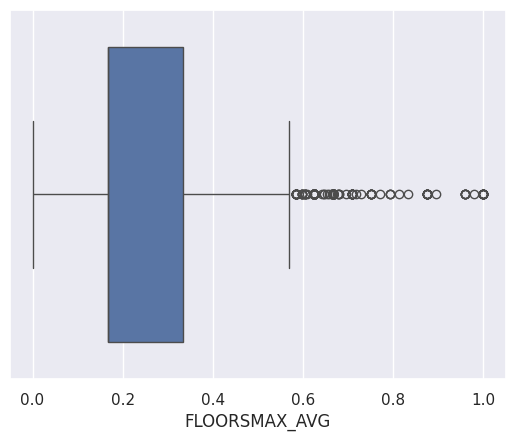

In [31]:
sns.boxplot(x = df['FLOORSMAX_AVG'])

In [33]:
df['FLOORSMAX_AVG'] = df['FLOORSMAX_AVG'].fillna(df['FLOORSMAX_AVG'].median())
df['FLOORSMAX_AVG'].isnull().sum()

0

In [34]:
df['EMERGENCYSTATE_MODE'] = df['EMERGENCYSTATE_MODE'].fillna('No')
df['EMERGENCYSTATE_MODE'].isnull().sum()

0

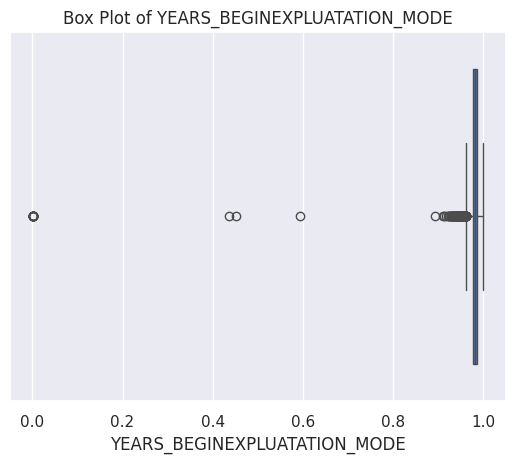

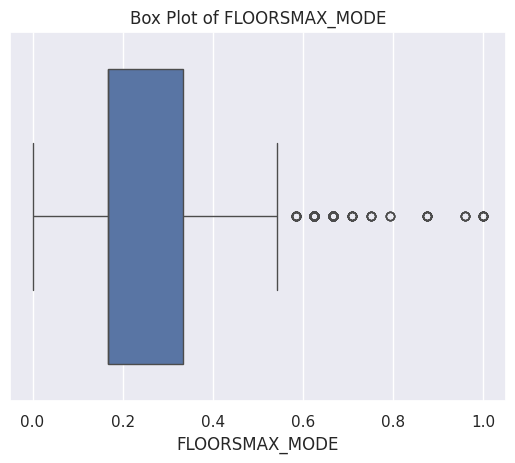

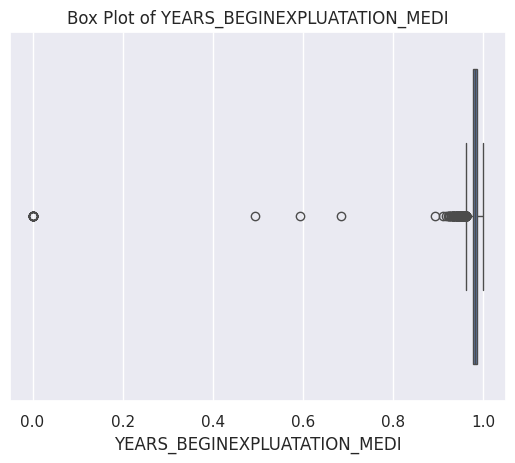

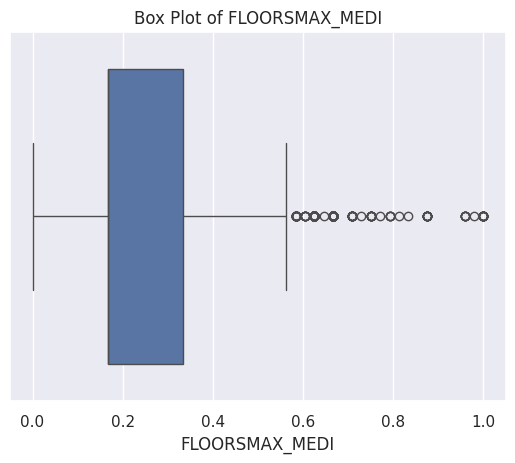

In [35]:
def box_plot(data):
    sns.boxplot(x=df[data])
    plt.title(f"Box Plot of {data}")
    plt.show()
# List of columns to plot
values = ['YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MEDI',
          'FLOORSMAX_MEDI']

# Loop through each column and create a box plot
for i in values:
    box_plot(i)

In [68]:
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].fillna('Business Entity Type 3')
df['ORGANIZATION_TYPE'].isnull().sum()

0

In [71]:
def fill_na_value(col_name):
    df[col_name] = df[col_name].fillna(df[col_name].median())

values = ['YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MEDI','REGION_RATING_CLIENT_W_CITY',
          'REGION_RATING_CLIENT', 'FLOORSMAX_AVG', 'YEARS_BEGINEXPLUATATION_MEDI','REGION_RATING_CLIENT',
          'FLOORSMAX_MEDI','YEARS_BEGINEXPLUATATION_MODE','OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
          'DEF_60_CNT_SOCIAL_CIRCLE','TOTALAREA_MODE','AMT_REQ_CREDIT_BUREAU_HOUR','AMT_REQ_CREDIT_BUREAU_DAY','AMT_REQ_CREDIT_BUREAU_WEEK','AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT','AMT_REQ_CREDIT_BUREAU_YEAR',
          'HOUR_APPR_PROCESS_START','REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION','LIVE_REGION_NOT_WORK_REGION','REG_CITY_NOT_LIVE_CITY','REG_CITY_NOT_WORK_CITY','LIVE_CITY_NOT_WORK_CITY',
          'DAYS_LAST_PHONE_CHANGE','FLAG_DOCUMENT_2','FLAG_DOCUMENT_3','FLAG_DOCUMENT_4',
          'FLAG_DOCUMENT_5','FLAG_DOCUMENT_6','FLAG_DOCUMENT_7','FLAG_DOCUMENT_8','FLAG_DOCUMENT_9',
          'FLAG_DOCUMENT_10','FLAG_DOCUMENT_11','FLAG_DOCUMENT_12','FLAG_DOCUMENT_13','FLAG_DOCUMENT_14' ,
          'FLAG_DOCUMENT_15','FLAG_DOCUMENT_16','FLAG_DOCUMENT_17','FLAG_DOCUMENT_18','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20',
          'FLAG_DOCUMENT_21'

          ]
for i in values:
    print(i)
    fill_na_value(i)

YEARS_BEGINEXPLUATATION_MODE
FLOORSMAX_MODE
YEARS_BEGINEXPLUATATION_MEDI
REGION_RATING_CLIENT_W_CITY
REGION_RATING_CLIENT
FLOORSMAX_AVG
YEARS_BEGINEXPLUATATION_MEDI
REGION_RATING_CLIENT
FLOORSMAX_MEDI
YEARS_BEGINEXPLUATATION_MODE
OBS_30_CNT_SOCIAL_CIRCLE
DEF_30_CNT_SOCIAL_CIRCLE
OBS_60_CNT_SOCIAL_CIRCLE
DEF_60_CNT_SOCIAL_CIRCLE
TOTALAREA_MODE
AMT_REQ_CREDIT_BUREAU_HOUR
AMT_REQ_CREDIT_BUREAU_DAY
AMT_REQ_CREDIT_BUREAU_WEEK
AMT_REQ_CREDIT_BUREAU_MON
AMT_REQ_CREDIT_BUREAU_QRT
AMT_REQ_CREDIT_BUREAU_YEAR
HOUR_APPR_PROCESS_START
REG_REGION_NOT_LIVE_REGION
REG_REGION_NOT_WORK_REGION
LIVE_REGION_NOT_WORK_REGION
REG_CITY_NOT_LIVE_CITY
REG_CITY_NOT_WORK_CITY
LIVE_CITY_NOT_WORK_CITY
DAYS_LAST_PHONE_CHANGE
FLAG_DOCUMENT_2
FLAG_DOCUMENT_3
FLAG_DOCUMENT_4
FLAG_DOCUMENT_5
FLAG_DOCUMENT_6
FLAG_DOCUMENT_7
FLAG_DOCUMENT_8
FLAG_DOCUMENT_9
FLAG_DOCUMENT_10
FLAG_DOCUMENT_11
FLAG_DOCUMENT_12
FLAG_DOCUMENT_13
FLAG_DOCUMENT_14
FLAG_DOCUMENT_15
FLAG_DOCUMENT_16
FLAG_DOCUMENT_17
FLAG_DOCUMENT_18
FLAG_DOCUMENT_19

In [37]:
df['OCCUPATION_TYPE'].value_counts()
df['OCCUPATION_TYPE']=df['OCCUPATION_TYPE'].fillna('Laborers')

<Axes: xlabel='CNT_FAM_MEMBERS'>

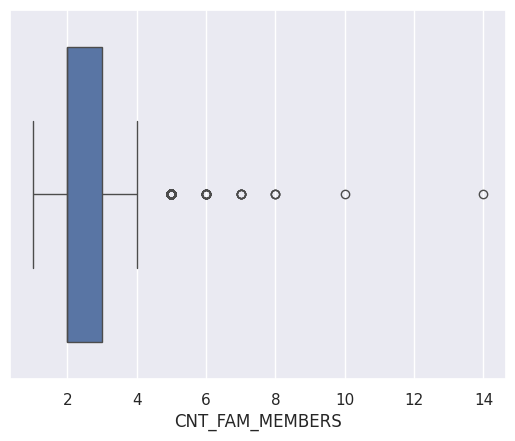

In [38]:
sns.boxplot(x=df['CNT_FAM_MEMBERS'])

In [40]:
df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].fillna(df['CNT_FAM_MEMBERS'].median())

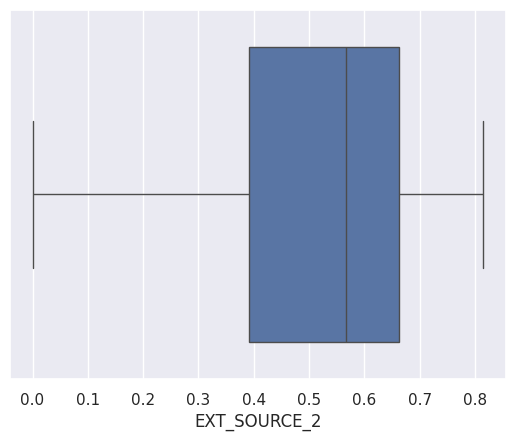

In [39]:
sns.boxplot(x=df['EXT_SOURCE_2'])
df['EXT_SOURCE_2'] = df['EXT_SOURCE_2'].fillna(df['EXT_SOURCE_2'].mean())

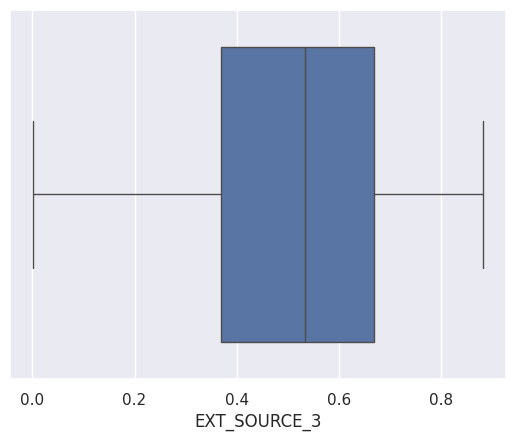

In [41]:
sns.boxplot(x=df['EXT_SOURCE_3'])
df['EXT_SOURCE_3'] = df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_3'].mean())

In [75]:
df['WEEKDAY_APPR_PROCESS_START']=df['WEEKDAY_APPR_PROCESS_START'].fillna('THURSDAY')

ID: 0
TARGET: 0
NAME_CONTRACT_TYPE: 0
CODE_GENDER: 0
FLAG_OWN_CAR: 0
FLAG_OWN_REALTY: 0
CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 0
NAME_TYPE_SUITE: 0
NAME_INCOME_TYPE: 0
NAME_EDUCATION_TYPE: 0
NAME_FAMILY_STATUS: 0
NAME_HOUSING_TYPE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_BIRTH: 0
DAYS_EMPLOYED: 0
DAYS_REGISTRATION: 0
DAYS_ID_PUBLISH: 0
FLAG_MOBIL: 0
FLAG_EMP_PHONE: 0
FLAG_WORK_PHONE: 0
FLAG_CONT_MOBILE: 0
FLAG_PHONE: 0
FLAG_EMAIL: 0
OCCUPATION_TYPE: 0
CNT_FAM_MEMBERS: 0
REGION_RATING_CLIENT: 0
REGION_RATING_CLIENT_W_CITY: 0
WEEKDAY_APPR_PROCESS_START: 1
HOUR_APPR_PROCESS_START: 0
REG_REGION_NOT_LIVE_REGION: 0
REG_REGION_NOT_WORK_REGION: 0
LIVE_REGION_NOT_WORK_REGION: 0
REG_CITY_NOT_LIVE_CITY: 0
REG_CITY_NOT_WORK_CITY: 0
LIVE_CITY_NOT_WORK_CITY: 0
ORGANIZATION_TYPE: 0
EXT_SOURCE_2: 0
EXT_SOURCE_3: 0
YEARS_BEGINEXPLUATATION_AVG: 0
FLOORSMAX_AVG: 0
YEARS_BEGINEXPLUATATION_MODE: 0
FLOORSMAX_MODE: 0
YEARS_BEGINEXPLUATATION_MEDI: 0
FLOORSMAX_MEDI: 0
TO

<Axes: >

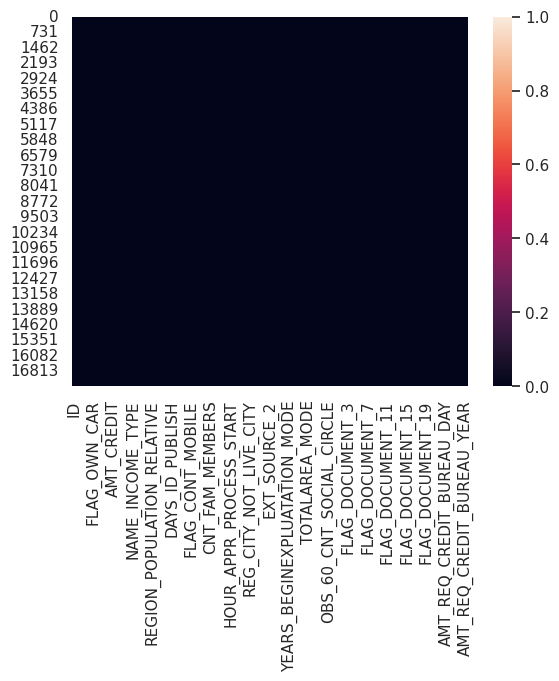

In [73]:
name_col = df.columns.tolist()
null_col = df.isnull().sum().tolist()
for (name, null) in zip(name_col, null_col):
    print(f'{name}: {null}')

sns.heatmap(df.isnull())

<Axes: xlabel='TOTALAREA_MODE'>

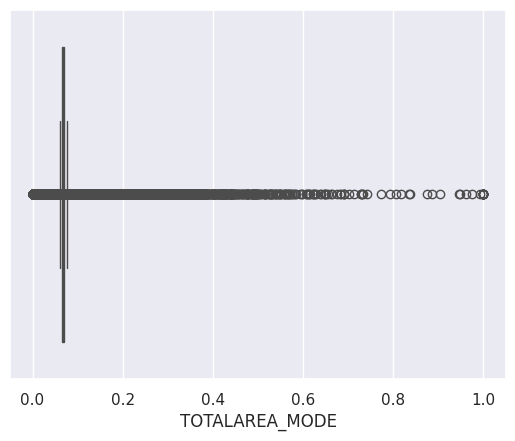

In [43]:
df['TOTALAREA_MODE'].value_counts()
sns.boxplot(x = df['TOTALAREA_MODE'])

<Axes: xlabel='TARGET', ylabel='count'>

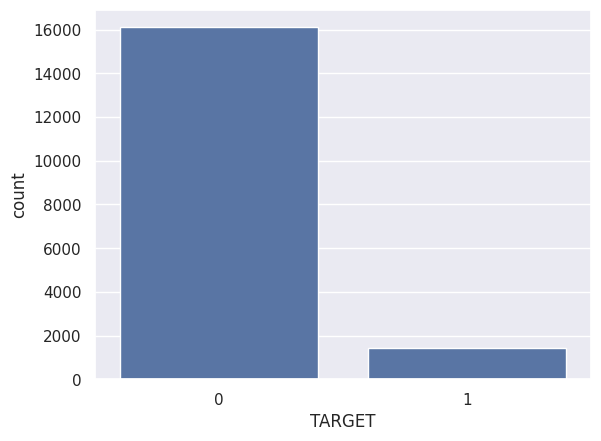

In [80]:
sns.countplot(x=df['TARGET'])

In [108]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

def classification_models(X, y, test_size=0.2, random_state=42):
    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test:", y_test.shape)

    # Apply SMOTE to the training data to handle class imbalance
    smote = SMOTE(random_state=random_state)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE - X_train_smote: {X_train_smote.shape}, y_train_smote: {y_train_smote.shape}")

    # List of models to evaluate
    models = [
        RandomForestClassifier(),
        GaussianNB(),
        LogisticRegression(max_iter=500, solver='liblinear'),
        SVC(),
        KNeighborsClassifier(n_neighbors=5),
        GradientBoostingClassifier(),
        AdaBoostClassifier(),
        ExtraTreesClassifier(),
        BaggingClassifier(),
        BernoulliNB()
    ]

    results = []

    for model in models:
        # Train the model
        model.fit(X_train_smote, y_train_smote)

        # Make predictions
        predicts = model.predict(X_test)

        # Evaluate the model
        print("Model:", model.__class__.__name__)
        print("Model Accuracy:", accuracy_score(predicts, y_test))
        print("Model Confusion Matrix:", confusion_matrix(predicts, y_test))
        print("Model Classification Report:", classification_report(predicts, y_test, zero_division=1))  # Handle undefined recall
        print(50 * "-")

        # Store results
        results.append(accuracy_score(predicts, y_test))

    # Get best model index
    best_model_idx = results.index(max(results))
    best_model = models[best_model_idx]
    print("Best Model:", best_model.__class__.__name__)
    print("Best Model Accuracy Score:", max(results))

    # Store results in DataFrame
    models_scores = pd.DataFrame({
        "Models": [model.__class__.__name__ for model in models],
        "Scores": results
    })

    # Sort models by score
    print(models_scores.sort_values(by='Scores', ascending=False, ignore_index=True))

    return best_model, X_train_smote, y_train_smote, X_test

# Load data
X = df.drop('TARGET', axis=1)
y = df['TARGET']

# Encode categorical features
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Prepare test data
df_test = pd.read_csv('/content/test.csv')
for col in df_test.columns:
    if df_test[col].dtype == 'object':
        df_test[col] = le.fit_transform(df_test[col])

# Ensure that test set has the same columns as training set
df_test = df_test[X.columns]

# Train models and get the best model
best_model, X_train_smote, y_train_smote, X_test = classification_models(X, y)

# Train the best model on the entire training dataset
best_model.fit(X_train_smote, y_train_smote)

# Predict on the test set
test_predictions = best_model.predict(df_test)

# Prepare the final submission dataframe
submission = pd.DataFrame({
    'ID': df_test['ID'],
    'TARGET': test_predictions
})

# Save the submission file
submission.to_csv('/content/ML_Learner.csv', index=False)



X_train: (14031, 80)
X_test: (3508, 80)
y_train: (14031,)
y_test: (3508,)
After SMOTE - X_train_smote: (25810, 80), y_train_smote: (25810,)
Model: RandomForestClassifier
Model Accuracy: 0.9119156214367161
Model Confusion Matrix: [[3196  297]
 [  12    3]]
Model Classification Report:               precision    recall  f1-score   support

           0       1.00      0.91      0.95      3493
           1       0.01      0.20      0.02        15

    accuracy                           0.91      3508
   macro avg       0.50      0.56      0.49      3508
weighted avg       0.99      0.91      0.95      3508

--------------------------------------------------
Model: GaussianNB
Model Accuracy: 0.9013683010262258
Model Confusion Matrix: [[3157  295]
 [  51    5]]
Model Classification Report:               precision    recall  f1-score   support

           0       0.98      0.91      0.95      3452
           1       0.02      0.09      0.03        56

    accuracy                           0

In [106]:
df_test.shape

(92253, 80)

In [109]:
team_name = pd.read_csv('/content/ML_Learner.csv')
team_name.shape

(92253, 2)